V. 1. Le Chirp
V.1.1. Le chirp linéaire d'amplitude constante

#Il faut fa>2*fmax (pire cas)

In [2]:
import numpy as np
Tobs= 5
Dobs= 1
fa=0
tempsa = np.linspace(0,Tobs,fa*Tobs) #Dobs = duree d'observation
#Naa représente les filtres
Naa=[tempsa[i] for i in range(0,Dobs*fa)]
Nab=[tempsa[i] for i in range((int)(Tobs/2-Dobs/2)*fa,(int)(Tobs/2+Dobs/2)*fa)]
Nac=[tempsa[i] for i in range((Tobs-Dobs)*fa,Tobs*fa)]

In [37]:
#ATTENTION IL FAUT NORMALISER LES FILTRES !!!!
def fta(L):
    M=[L[0]*0.6]
    for i in range(1,len(L)):
        M.append(M[i-1]*1j*0.4+L[i])
    M=[M[i]*0.6 for i in range(len(M))]
    return M
    
def ftb(L):
    M=[L[0]*0.4]
    for i in range(1,len(L)):
        M.append(M[i-1]*-0.6+L[i])
    M=[M[i]*0.4 for i in range(len(M))]
    return M
    
def ftc(L):
    M=[L[0]*0.2]
    for i in range(1,len(L)):
        M.append(M[i-1]*-1j*0.8+L[i])
    M=[M[i]*0.2 for i in range(len(M))]
    return M
    
def genere_chirp(fa,fmin,fmax,Tobs,Dobs):
    chirpa=[]
    tempsa = np.linspace(0,Tobs,fa*Tobs)
    T1=[tempsa[i] for i in range(0,(int)(Dobs*fa))]
    T2=[tempsa[i] for i in range((int)((Tobs/2-Dobs/2)*fa),(int)((Tobs/2+Dobs/2)*fa))]
    T3=[tempsa[i] for i in range((int)((Tobs-Dobs)*fa),Tobs*fa)]
    
    b=(fmax-fmin)/Tobs
    f_chirp = lambda x : np.cos(2*np.pi*x*(fmin+b*x/2))
    chirp=[f_chirp(e) for e in tempsa]
    
    chirp1=[f_chirp(e) for e in T1]
    chirpa1=fta(chirp1)
    chirpb1=ftb(chirp1)
    chirpc1=ftc(chirp1)
    
    chirp2=[f_chirp(e) for e in T2]
    chirpa2=fta(chirp2)
    chirpb2=ftb(chirp2)
    chirpc2=ftc(chirp2)

    chirp3=[f_chirp(e) for e in T3]
    chirpa3=fta(chirp3)
    chirpb3=ftb(chirp3)
    chirpc3=ftc(chirp3)
    
    return tempsa,T1,T2,T3,chirp1,chirpa1,chirpb1,chirpc1,chirp2,chirpa2,chirpb2,chirpc2,chirp3,chirpa3,chirpb3,chirpc3
    

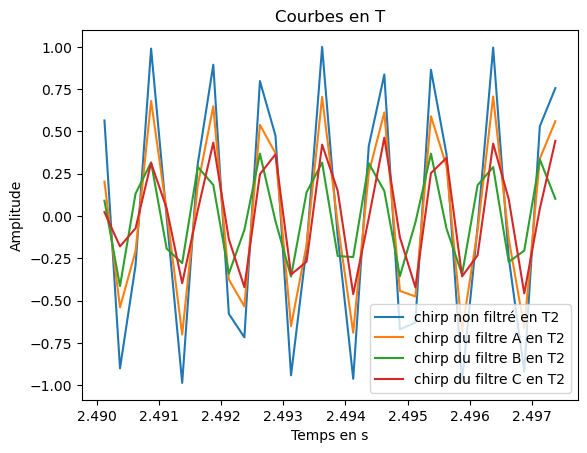

In [39]:
import matplotlib.pyplot as plt
P=genere_chirp(4000,200,2000,5,0.02)
plt.plot(P[2][:30],P[8][:30],label='chirp non filtré en T2')
plt.plot(P[2][:30],P[9][:30],label='chirp du filtre A en T2')
plt.plot(P[2][:30],P[10][:30],label='chirp du filtre B en T2')
plt.plot(P[2][:30],P[11][:30],label='chirp du filtre C en T2')

plt.xlabel('Temps en s')
plt.ylabel('Amplitude')
plt.title('Courbes en T')
plt.legend()

plt.show()

In [29]:
print(np.sqrt(1+0.8*0.8))

1.2806248474865698


In [40]:
def fta(L):
    M=[L[0]*0.6]
    for i in range(1,len(L)):
        M.append(M[i-1]*1j*0.4+L[i])
    M=[M[i]*0.6 for i in range(len(M))]
    return M
    
def ftb(L):
    M=[L[0]*0.4]
    for i in range(1,len(L)):
        M.append(M[i-1]*-0.6+L[i])
    M=[M[i]*0.4 for i in range(len(M))]
    return M
    
def ftc(L):
    M=[L[0]*0.2]
    for i in range(1,len(L)):
        M.append(M[i-1]*-1j*0.8+L[i])
    M=[M[i]*0.2 for i in range(len(M))]
    return M
    
def genere_chirp(fa,fmin,fmax,Tobs,Dobs):
    chirpa=[]
    tempsa = np.linspace(0,Tobs,fa*Tobs)
    T1=[tempsa[i] for i in range(0,(int)(Dobs*fa))]
    T2=[tempsa[i] for i in range((int)((Tobs/2-Dobs/2)*fa),(int)((Tobs/2+Dobs/2)*fa))]
    T3=[tempsa[i] for i in range((int)((Tobs-Dobs)*fa),Tobs*fa)]
    
    b=(fmax-fmin)/Tobs
    f_chirp = lambda x : np.cos(2*np.pi*x*(fmin+b*x/2))
    chirp1=[f_chirp(e) for e in tempsa]
    chirpa=fta(chirp1)
    chirpb=ftb(chirp1)
    chirpc=ftc(chirp1)
    
    return tempsa,chirp1,chirpa,chirpb,chirpc

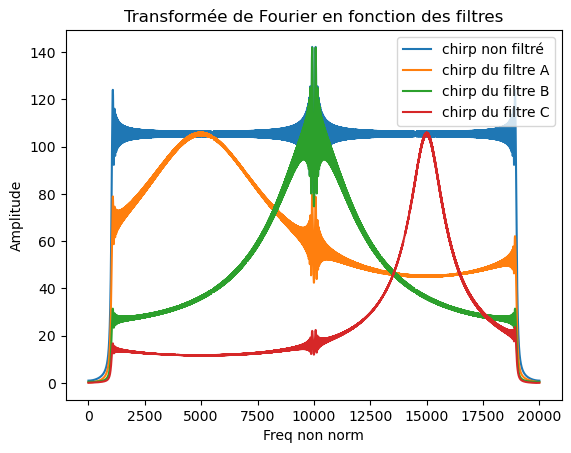

In [42]:
P=genere_chirp(4000,200,2000,5,0.02)
plt.plot(f,np.abs(np.fft.fft(P[1])),label='chirp non filtré')
plt.plot(f,np.abs(np.fft.fft(P[2])),label='chirp du filtre A')
plt.plot(f,np.abs(np.fft.fft(P[3])),label='chirp du filtre B')
plt.plot(f,np.abs(np.fft.fft(P[4])),label='chirp du filtre C')

plt.xlabel('Freq non norm')
plt.ylabel('Amplitude')
plt.title('Transformée de Fourier en fonction des filtres')
plt.legend()

plt.show()